**Capstone Project-1: Forest Cover Type Prediction**

In [ ]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             classification_report)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import lightgbm as lgb

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

print('Setup complete.')

Setup complete.


Data Loading and Inspection

In [ ]:
!unzip /content/Forest_Cover_Data_Type.zip

Archive:  /content/Forest_Cover_Data_Type.zip
  inflating: covtype.csv             


In [ ]:
#Load the dataset using pandas.
df=pd.read_csv('/content/covtype.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (581012, 55)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [ ]:
df['Cover_Type'].value_counts()

,count
Cover_Type,
2,283301
1,211840
3,35754
7,20510
6,17367
5,9493
4,2747


In [ ]:
#Check for missing values and data types.
df.isnull().sum()

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

In [ ]:
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


Cover_Type
2    283301
1    211840
3     35754
7     20510
6     17367
5      9493
4      2747
Name: count, dtype: int64


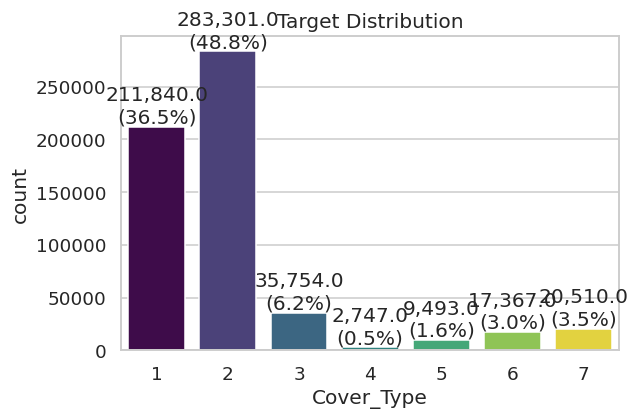

In [ ]:
#target variable distribution.
target_counts = df['Cover_Type'].value_counts()
print(target_counts)

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='Cover_Type', data=df, ax=ax, palette='viridis', hue='Cover_Type', legend=False)
ax.set_title('Target Distribution')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}\n({p.get_height()/len(df)*100:.1f}%)',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Exploratory Data Analysis (EDA)**

In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print(f'Numeric ({len(num_cols)}): {num_cols}')

Numeric (55): ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points', 'Wilderness_Area1', 'Wilderness_Area2', 'Wilderness_Area3', 'Wilderness_Area4', 'Soil_Type1', 'Soil_Type2', 'Soil_Type3', 'Soil_Type4', 'Soil_Type5', 'Soil_Type6', 'Soil_Type7', 'Soil_Type8', 'Soil_Type9', 'Soil_Type10', 'Soil_Type11', 'Soil_Type12', 'Soil_Type13', 'Soil_Type14', 'Soil_Type15', 'Soil_Type16', 'Soil_Type17', 'Soil_Type18', 'Soil_Type19', 'Soil_Type20', 'Soil_Type21', 'Soil_Type22', 'Soil_Type23', 'Soil_Type24', 'Soil_Type25', 'Soil_Type26', 'Soil_Type27', 'Soil_Type28', 'Soil_Type29', 'Soil_Type30', 'Soil_Type31', 'Soil_Type32', 'Soil_Type33', 'Soil_Type34', 'Soil_Type35', 'Soil_Type36', 'Soil_Type37', 'Soil_Type38', 'Soil_Type39', 'Soil_Type40', 'Cover_Type']


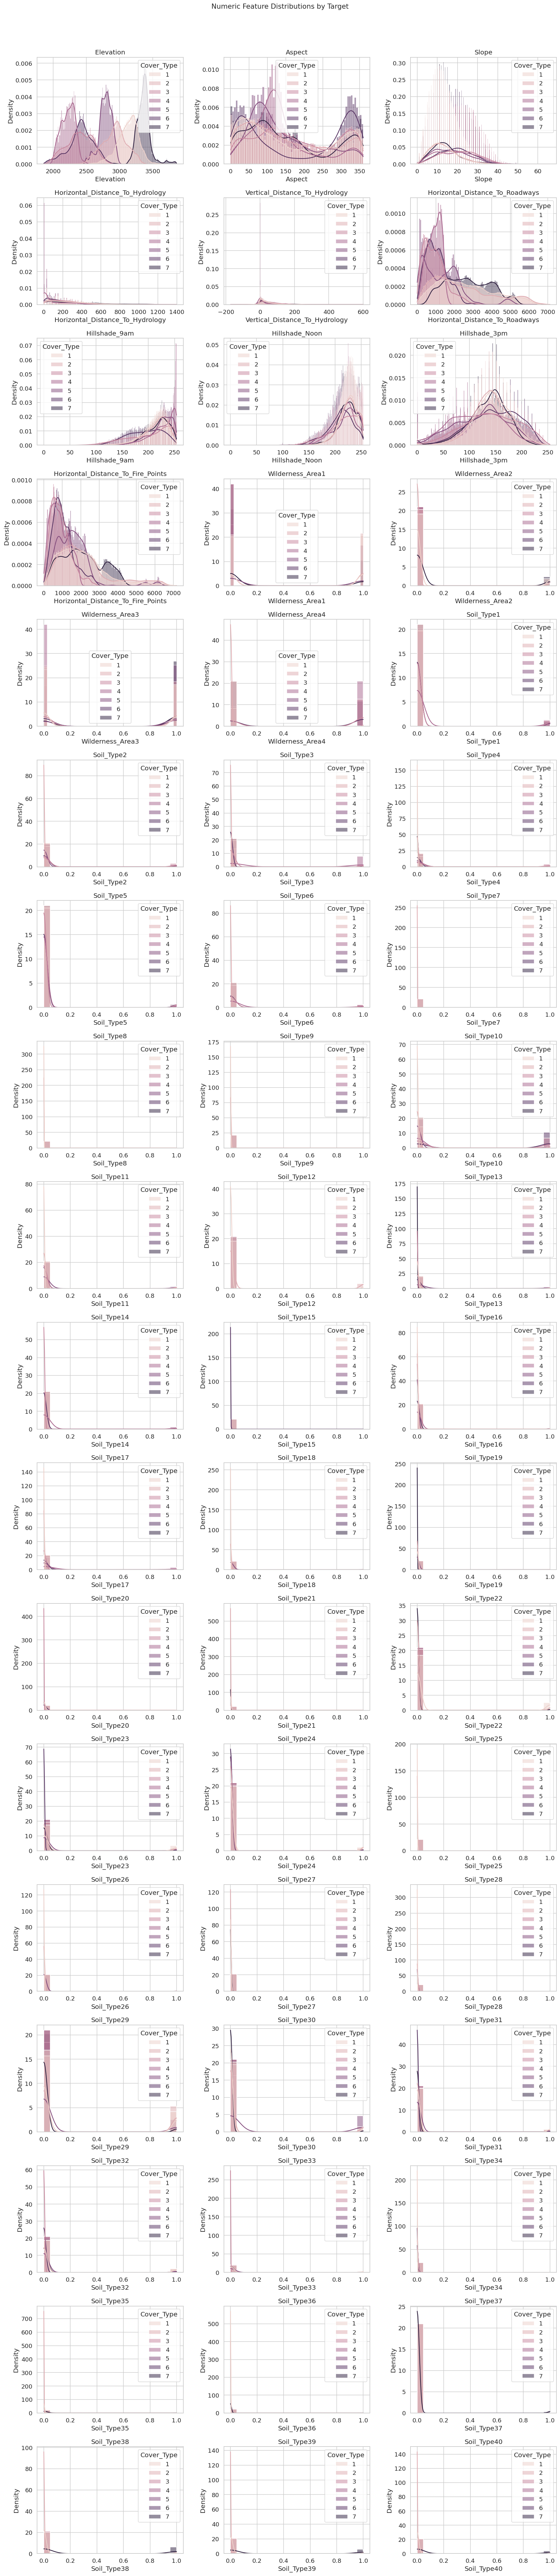

In [ ]:
#feature distributions
num_cols_to_plot = [col for col in num_cols if col != 'Cover_Type'] # Exclude target variable from feature plots
num_plots = len(num_cols_to_plot)
num_cols_per_row = 3
num_rows = (num_plots + num_cols_per_row - 1) // num_cols_per_row # Calculate required rows

fig, axes = plt.subplots(num_rows, num_cols_per_row, figsize=(16, 4 * num_rows))
axes_flat = axes.flatten()

for i, col in enumerate(num_cols_to_plot):
    sns.histplot(data=df, x=col, hue='Cover_Type', kde=True, ax=axes_flat[i],
                 stat='density', common_norm=False, alpha=0.5)
    axes_flat[i].set_title(col)

# Hide any unused subplots
for j in range(num_plots, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions by Target', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### Correlation Analysis

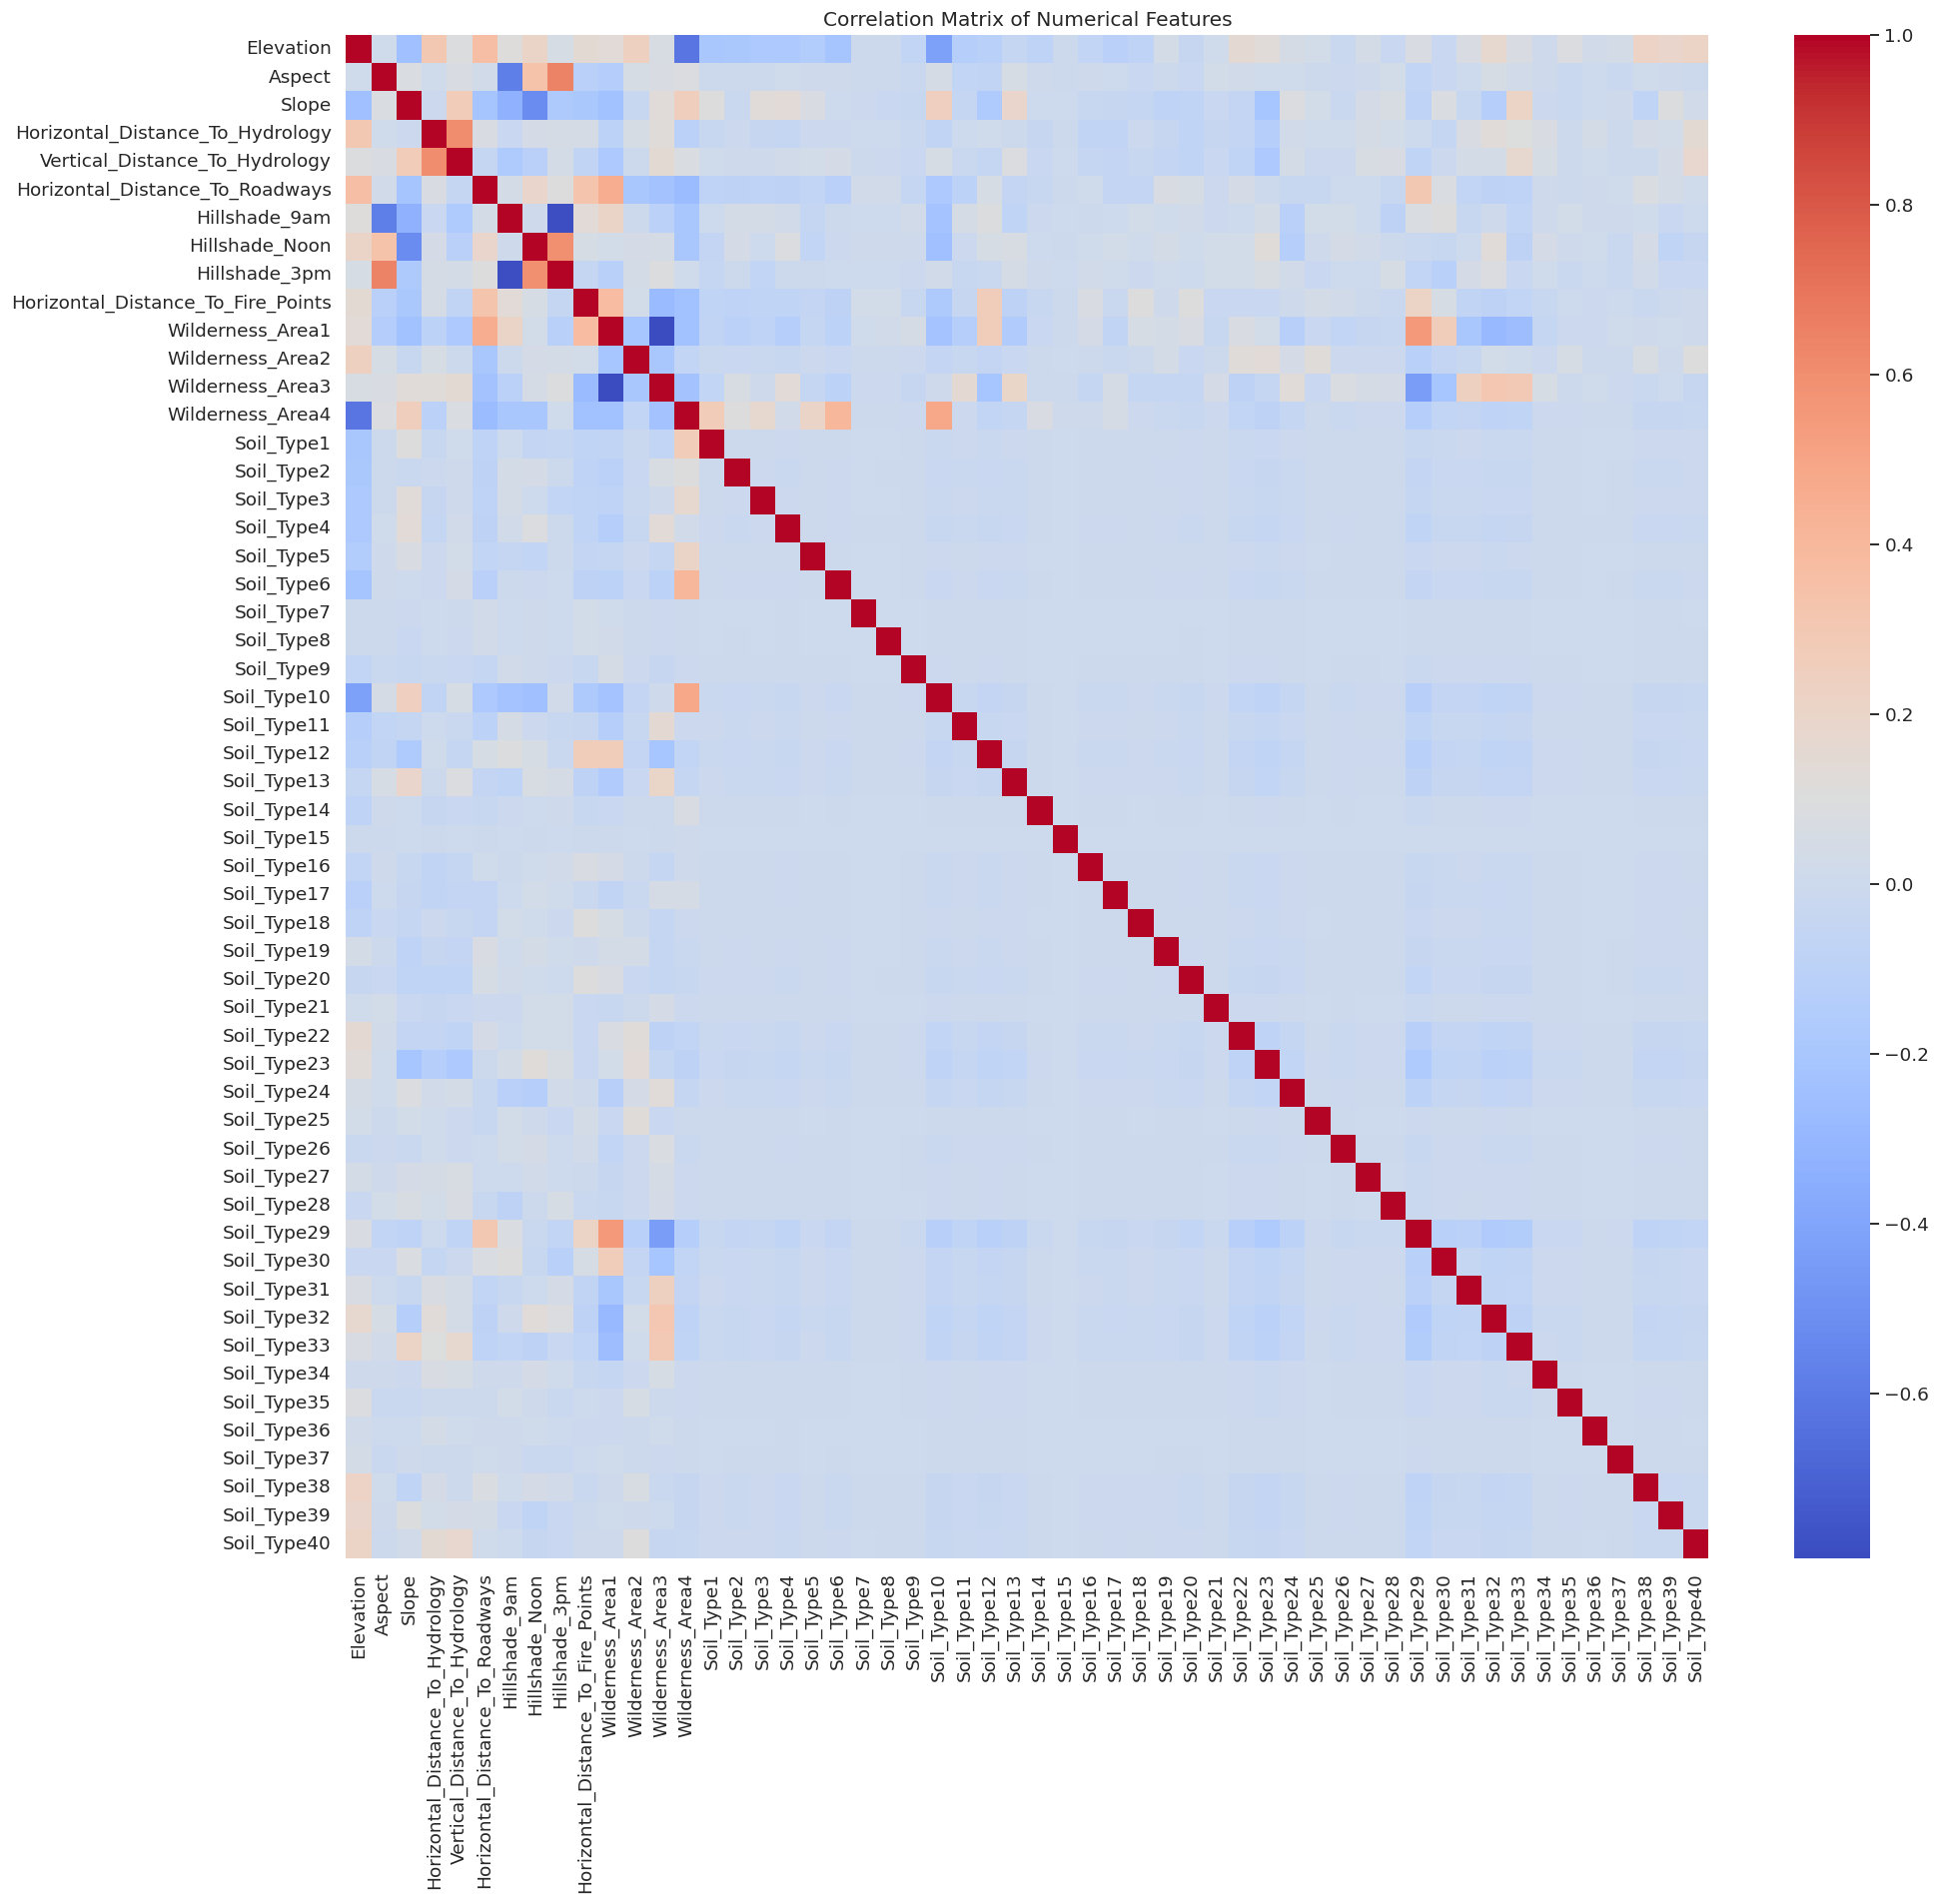

In [ ]:
plt.figure(figsize=(20, 18))
sns.heatmap(df[num_cols_to_plot].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
correlation_with_target = df.corr()['Cover_Type'].sort_values(ascending=False)
display(correlation_with_target)

,Cover_Type
Cover_Type,1.000000
Wilderness_Area4,0.323200
Soil_Type10,0.243876
Soil_Type38,0.160170
Soil_Type39,0.155668
Slope,0.148285
Soil_Type40,0.128351
Soil_Type2,0.118135
Soil_Type6,0.112958
Soil_Type4,0.099672


 **Data Preprocessing**

In [ ]:
X = df.drop(columns=['Cover_Type'])
y = df['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Adjust target labels to be 0-indexed for models like XGBoost and LightGBM
y_train = y_train - 1
y_test = y_test - 1

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train target distribution:\n{y_train.value_counts(normalize=True)}')


Train: (464809, 54), Test: (116203, 54)
Train target distribution:
Cover_Type
1    0.487598
0    0.364606
2    0.061537
6    0.035301
5    0.029892
4    0.016338
3    0.004729
Name: proportion, dtype: float64


In [ ]:
#Preprocessing Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_to_plot)

    ]
)

**Model Building**

In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, cv=5):
    """Fit model, predict, return metrics dict, including cross-validation F1 score."""
    # Cross-validation setup
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)

    # Calculate cross-validation F1 score
    cv_f1 = cross_val_score(model, X_tr, y_tr, cv=skf, scoring='f1_weighted', n_jobs=-1, error_score=0)

    # Fit model on the full training data and predict on test set
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision (weighted)': precision_score(y_te, y_pred, average='weighted', zero_division=0),
        'Recall (weighted)': recall_score(y_te, y_pred, average='weighted', zero_division=0),
        'F1 (weighted)': f1_score(y_te, y_pred, average='weighted', zero_division=0),
         'CV F1 (weighted)': np.mean(cv_f1),
    }
    return metrics, y_pred

baselines = {
   'Logistic Regression': Pipeline([('pre', preprocessor),
                                      ('clf', LogisticRegression(max_iter=1000, random_state=SEED))]),
    'Decision Tree':       Pipeline([('pre', preprocessor),
                                      ('clf', DecisionTreeClassifier(random_state=SEED, max_depth = 15,min_samples_leaf=2))]),
    'Random Forest(balanced) ': Pipeline([('pre', preprocessor),
                                         ('clf', RandomForestClassifier(n_estimators=200,
                                                                          max_depth=20,
                                                                          class_weight='balanced',
                                                                          random_state=SEED, n_jobs=-1))]),
    'XGBoost': Pipeline([
        ('pre', preprocessor),
      ('clf', XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                              random_state=SEED,
                              eval_metric='mlogloss',
                              use_label_encoder=False
                             ))
    ]),
   'LightGBM': Pipeline([
        ('pre', preprocessor),
       ('clf', lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=SEED))
    ])
}

results = []
preds = {}

for name, pipe in baselines.items():
    m, yp = evaluate_model(name, pipe, X_train, y_train, X_test, y_test)
    results.append(m)
    preds[name] = yp
    # Updated print statement to include CV F1 score
    print(f'{name}: F1={m["F1 (weighted)"]:.3f}, Accuracy={m["Accuracy"]:.3f}), CV F1={m["CV F1 (weighted)"]:.3f}')

results_df = pd.DataFrame(results).set_index('Model')
display(results_df.round(3))


Logistic Regression: F1=0.714, Accuracy=0.723), CV F1=0.715
Decision Tree: F1=0.847, Accuracy=0.849), CV F1=0.849
Random Forest(balanced) : F1=0.904, Accuracy=0.902), CV F1=0.901
XGBoost: F1=0.813, Accuracy=0.815), CV F1=0.813
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.127394 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2145
[LightGBM] [Info] Number of data points in the train set: 464809, number of used features: 53
[LightGBM] [Info] Start training from score -1.008939
[LightGBM] [Info] Start training from score -0.718264
[LightGBM] [Info] Start training from score -2.788115
[LightGBM] [Info] Start training from score -5.354079
[LightGBM] [Info] Start training from score -4.114268
[LightGBM] [Info] Start training from score -3.510169
[LightGBM] [Info] Start training from score -3.343858
LightGBM: F1=0.898, Accuracy=0.898), CV F

,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),CV F1 (weighted)
Model,,,,,
Logistic Regression,0.723,0.711,0.723,0.714,0.715
Decision Tree,0.849,0.850,0.849,0.847,0.849
Random Forest(balanced),0.902,0.908,0.902,0.904,0.901
XGBoost,0.815,0.815,0.815,0.813,0.813
LightGBM,0.898,0.898,0.898,0.898,0.899


**Neural Network Model**

In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Prepare data for PyTorch
# Scale X_train and X_test using the preprocessor
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# Create TensorDatasets and DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

# Define the Neural Network model
class NeuralNet(nn.Module):
    def __init__(self, input_size, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        return out

input_size = X_train_scaled.shape[1]
num_classes = len(y_train.unique()) # Number of unique cover types

model = NeuralNet(input_size, num_classes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    for i, (inputs, labels) in enumerate(train_loader):
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print (f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluate the model
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    nn_f1_weighted = f1_score(all_labels, all_preds, average='weighted')
    nn_precision_weighted = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    nn_recall_weighted = recall_score(all_labels, all_preds, average='weighted', zero_division=0)

    print(f'Accuracy of the Neural Network on the test set: {accuracy:.2f}%')
    print(f'F1 Score (weighted) of the Neural Network on the test set: {nn_f1_weighted:.3f}')

# Add Neural Network results to the results_df
nn_results = {
    'Model': 'Neural Network',
    'Accuracy': accuracy / 100,
    'Precision (weighted)': nn_precision_weighted,
    'Recall (weighted)': nn_recall_weighted,
    'F1 (weighted)': nn_f1_weighted
}

results.append(nn_results)
results_df = pd.DataFrame(results).set_index('Model')
display(results_df.round(3))

Epoch [1/10], Loss: 0.4961
Epoch [2/10], Loss: 0.4409
Epoch [3/10], Loss: 0.3755
Epoch [4/10], Loss: 0.4496
Epoch [5/10], Loss: 0.3797
Epoch [6/10], Loss: 0.3309
Epoch [7/10], Loss: 0.3266
Epoch [8/10], Loss: 0.3162
Epoch [9/10], Loss: 0.2137
Epoch [10/10], Loss: 0.2930
Accuracy of the Neural Network on the test set: 86.07%
F1 Score (weighted) of the Neural Network on the test set: 0.860


,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),CV F1 (weighted)
Model,,,,,
Logistic Regression,0.723,0.711,0.723,0.714,0.715
Decision Tree,0.902,0.902,0.902,0.901,0.899
Random Forest(balanced),0.902,0.908,0.902,0.904,0.901
XGBoost,0.815,0.815,0.815,0.813,0.813
LightGBM,0.898,0.898,0.898,0.898,0.899
Neural Network,0.861,0.861,0.861,0.860,NaN


Applying SMOTE

In [ ]:

from imblearn.over_sampling import SMOTE

# Apply SMOTE to the scaled training data
sm = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = sm.fit_resample(X_train_scaled, y_train)

print(f'Original training data shape: {X_train_scaled.shape}, {y_train.shape}')
print(f'SMOTE-augmented training data shape: {X_train_smote.shape}, {y_train_smote.shape}')
print(f'SMOTE-augmented target distribution:\n{pd.Series(y_train_smote).value_counts(normalize=True)}')


# Define raw classifiers that will be trained on SMOTE-augmented, scaled data
# The preprocessor and SMOTE steps are removed from these 'pipelines'
# because X_train_smote and X_test_scaled are already preprocessed.
smote_classifiers = {
    #'Logistic Regression + SMOTE': LogisticRegression(max_iter=1000, random_state=SEED),
    #'Decision Tree + SMOTE': DecisionTreeClassifier(random_state=SEED),
    'Random Forest + SMOTE': RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1,max_depth =15),
    #'XGBoost + SMOTE': XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                             # random_state=SEED,
                             # eval_metric='mlogloss',
                              #use_label_encoder=False
                            # ),
    #'LightGBM + SMOTE': lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=SEED)
}

# Initialize results_smote before use
results_smote = []
# Remove previous SMOTE results to re-run all
results_smote = [r for r in results_smote if '+ SMOTE' not in r['Model']]

print('\nRe-evaluating models with pre-applied SMOTE and scaled data...')

for name, clf in smote_classifiers.items():
    # Pass already SMOTE-augmented and scaled training data (X_train_smote, y_train_smote)
    # and already scaled test data (X_test_scaled, y_test)
    m, yp = evaluate_model(name, clf, X_train_smote, y_train_smote, X_test_scaled, y_test)
    results_smote.append(m)
    preds[name] = yp
    print(f'{name}: F1={m["F1 (weighted)"]:.3f}, Accuracy={m["Accuracy"]:.3f}')

results_sm_df = pd.DataFrame(results_smote).set_index('Model')
display(results_sm_df.round(3))

In [ ]:
# Apply SMOTE to the scaled training data
sm = SMOTE(random_state=SEED)
X_train_smote, y_train_smote = sm.fit_resample(X_train_scaled, y_train)

print(f'Original training data shape: {X_train_scaled.shape}, {y_train.shape}')
print(f'SMOTE-augmented training data shape: {X_train_smote.shape}, {y_train_smote.shape}')
print(f'SMOTE-augmented target distribution:\n{pd.Series(y_train_smote).value_counts(normalize=True)}')

# Convert SMOTE-augmented data to PyTorch tensors
X_train_smote_tensor = torch.tensor(X_train_smote, dtype=torch.float32)
y_train_smote_tensor = torch.tensor(y_train_smote.values, dtype=torch.long)

# Create TensorDataset and DataLoader for SMOTE-augmented training data
train_dataset_smote = TensorDataset(X_train_smote_tensor, y_train_smote_tensor)
train_loader_smote = DataLoader(train_dataset_smote, batch_size=256, shuffle=True)

# Re-initialize the Neural Network model to ensure a fresh start
model_smote_nn = NeuralNet(input_size, num_classes).to(device)

# Loss and optimizer for the SMOTE-trained model
criterion_smote = nn.CrossEntropyLoss()
optimizer_smote = optim.Adam(model_smote_nn.parameters(), lr=0.001)

# Train the Neural Network model with SMOTE-augmented data
print('\nTraining Neural Network with SMOTE-augmented data...')
for epoch in range(num_epochs):
    model_smote_nn.train()
    for i, (inputs, labels) in enumerate(train_loader_smote):
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model_smote_nn(inputs)
        loss = criterion_smote(outputs, labels)

        # Backward and optimize
        optimizer_smote.zero_grad()
        loss.backward()
        optimizer_smote.step()

    print (f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

# Evaluate the SMOTE-trained Neural Network model on the original test set
model_smote_nn.eval()
with torch.no_grad():
    correct_smote = 0
    total_smote = 0
    all_preds_smote = []
    all_labels_smote = []
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model_smote_nn(inputs)
        _, predicted = torch.max(outputs.data, 1)
        total_smote += labels.size(0)
        correct_smote += (predicted == labels).sum().item()
        all_preds_smote.extend(predicted.cpu().numpy())
        all_labels_smote.extend(labels.cpu().numpy())

    accuracy_smote = 100 * correct_smote / total_smote
    nn_smote_f1_weighted = f1_score(all_labels_smote, all_preds_smote, average='weighted', zero_division=0)
    nn_smote_precision_weighted = precision_score(all_labels_smote, all_preds_smote, average='weighted', zero_division=0)
    nn_smote_recall_weighted = recall_score(all_labels_smote, all_preds_smote, average='weighted', zero_division=0)

    print(f'Accuracy of Neural Network with SMOTE on the test set: {accuracy_smote:.2f}%')
    print(f'F1 Score (weighted) of Neural Network with SMOTE on the test set: {nn_smote_f1_weighted:.3f}')

# Add Neural Network (SMOTE) results to the results_df
nn_smote_results = {
    'Model': 'Neural Network + SMOTE',
    'Accuracy': accuracy_smote / 100,
    'Precision (weighted)': nn_smote_precision_weighted,
    'Recall (weighted)': nn_smote_recall_weighted,
    'F1 (weighted)': nn_smote_f1_weighted
}

results.append(nn_smote_results)
results_df = pd.DataFrame(results).set_index('Model')
display(results_df.round(3))

Original training data shape: (464809, 54), (464809,)
SMOTE-augmented training data shape: (1586480, 54), (1586480,)
SMOTE-augmented target distribution:
Cover_Type
1    0.142857
6    0.142857
0    0.142857
4    0.142857
2    0.142857
3    0.142857
5    0.142857
Name: proportion, dtype: float64

Training Neural Network with SMOTE-augmented data...
Epoch [1/10], Loss: 0.2556
Epoch [2/10], Loss: 0.2515
Epoch [3/10], Loss: 0.2094
Epoch [4/10], Loss: 0.1796
Epoch [5/10], Loss: 0.1652
Epoch [6/10], Loss: 0.1434
Epoch [7/10], Loss: 0.2214
Epoch [8/10], Loss: 0.2082
Epoch [9/10], Loss: 0.2504
Epoch [10/10], Loss: 0.1248
Accuracy of Neural Network with SMOTE on the test set: 84.90%
F1 Score (weighted) of Neural Network with SMOTE on the test set: 0.851


,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted)
Model,,,,
Random Forest (balanced),0.811,0.840,0.811,0.819
Neural Network,0.863,0.864,0.863,0.862
Neural Network + SMOTE,0.849,0.862,0.849,0.851


### Confusion Matrices

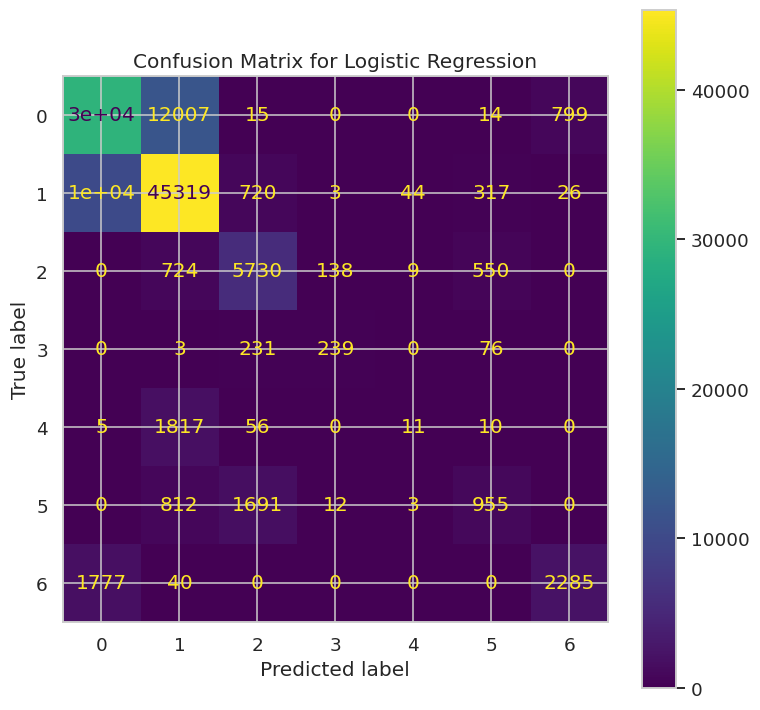

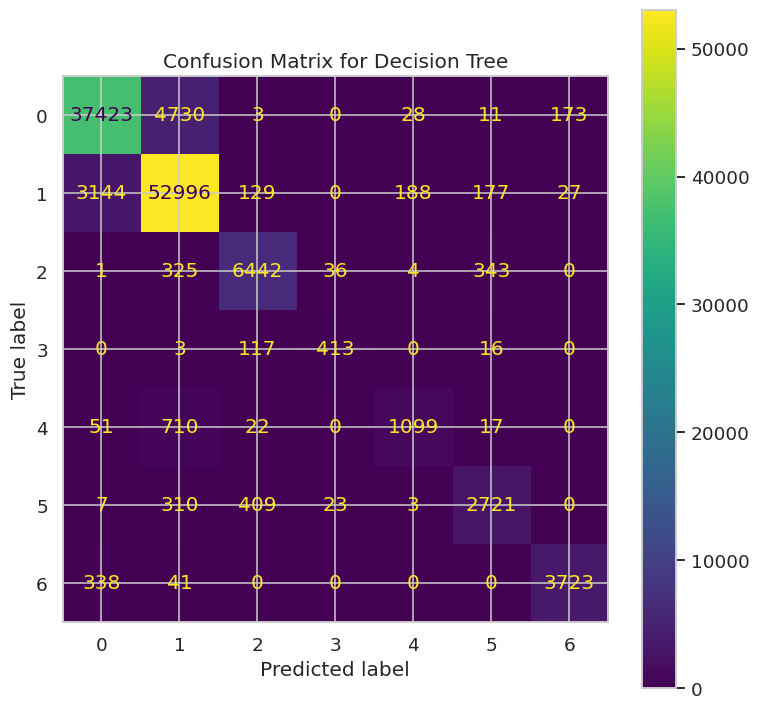

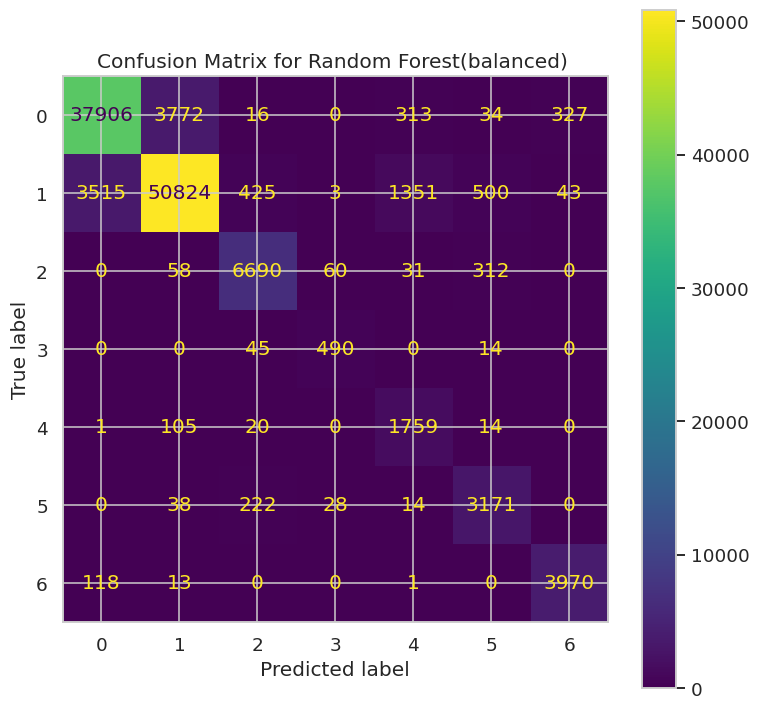

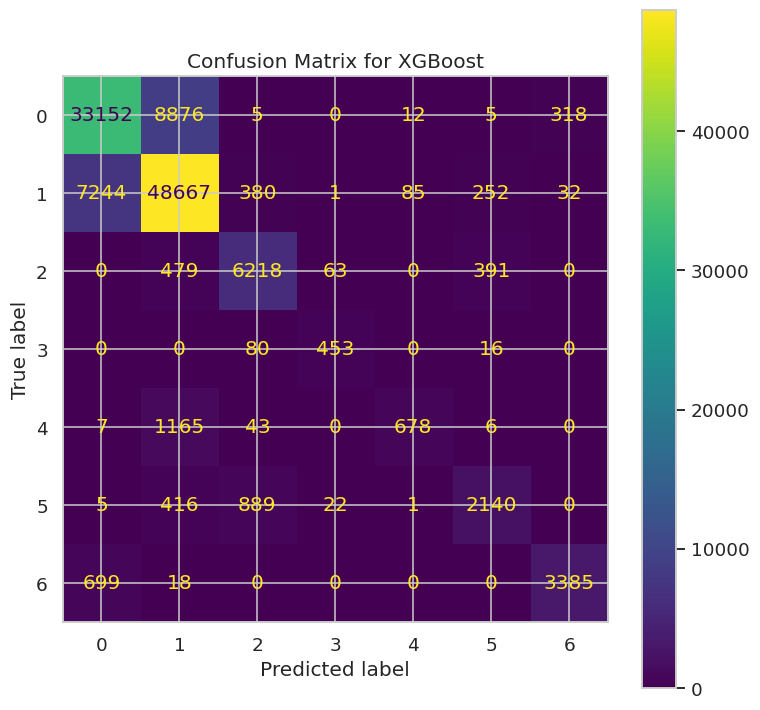

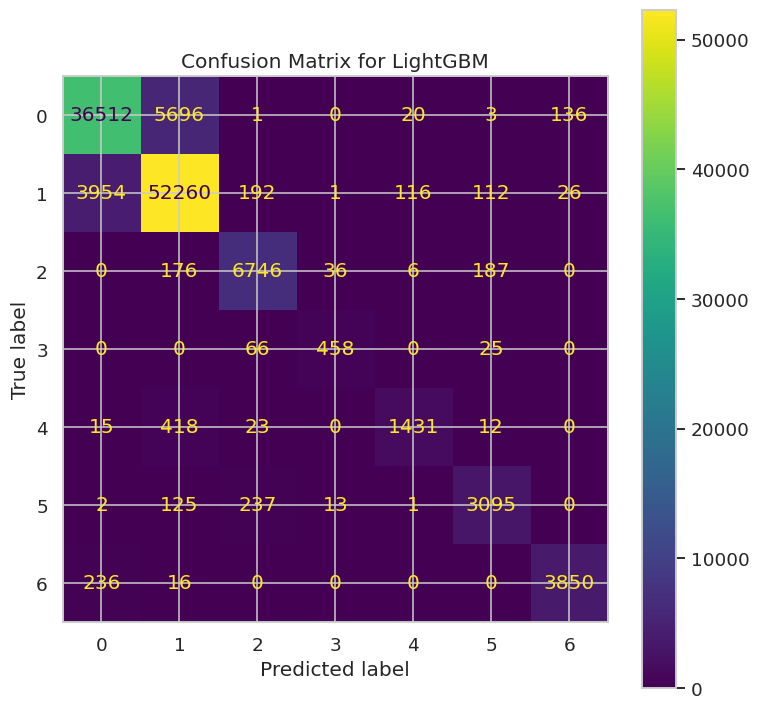

In [ ]:
for name, y_pred_model in preds.items():
    cm = confusion_matrix(y_test, y_pred_model)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(cmap='viridis', ax=ax)
    ax.set_title(f'Confusion Matrix for {name}')
    plt.show()


### Model Performance Summary

In [ ]:
final_results_df = pd.concat([results_df])
display(final_results_df.round(3))


,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),CV F1 (weighted)
Model,,,,,
Logistic Regression,0.723,0.711,0.723,0.714,0.715
Decision Tree,0.849,0.850,0.849,0.847,0.849
Random Forest(balanced),0.902,0.908,0.902,0.904,0.901
XGBoost,0.815,0.815,0.815,0.813,0.813
LightGBM,0.898,0.898,0.898,0.898,0.899


**Hyperparameter Tuning**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

SEED = 42
X_tune = X_train.sample(
    frac=0.25,
    random_state=42
)

y_tune = y_train.loc[X_tune.index]

# Base Random Forest model
rf_balanced_clf = RandomForestClassifier(
    random_state=SEED,
    class_weight='balanced',
    n_jobs=-1
)

# Expanded parameter distributions for more comprehensive search
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500], # Expanded range
    'max_depth': [10, 20, 30, 40],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

# Randomized Search with more iterations
random_search_rf = RandomizedSearchCV(
    estimator=rf_balanced_clf,
    param_distributions=param_dist,
    n_iter=50,  # Increased number of random combinations to test
    scoring='f1_weighted',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED), # Increased folds for CV
    random_state=SEED,
    n_jobs=-1,
    verbose=2
)

print("Starting RandomizedSearchCV for Balanced Random Forest (Comprehensive Search)...")

random_search_rf.fit(X_tune, y_tune)

print("RandomizedSearchCV finished.")

# Best parameters
print("\nBest Parameters:")
print(random_search_rf.best_params_)

print(f"\nBest CV F1-Weighted Score: {random_search_rf.best_score_:.3f}")

# Best model
best_rf_balanced_model = random_search_rf.best_estimator_

# Predictions
y_pred_tuned_rf_balanced = best_rf_balanced_model.predict(X_test)

# Evaluation
accuracy = accuracy_score(y_test, y_pred_tuned_rf_balanced)
precision = precision_score(
    y_test,
    y_pred_tuned_rf_balanced,
    average='weighted',
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred_tuned_rf_balanced,
    average='weighted',
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred_tuned_rf_balanced,
    average='weighted',
    zero_division=0
)

# Results
tuned_rf_results = {
    'Model': 'Random Forest (Balanced, Comprehensive Random Search)', # Updated model name
    'Accuracy': accuracy,
    'Precision (weighted)': precision,
    'Recall (weighted)': recall,
    'F1 (weighted)': f1,
    'CV F1 (weighted)': random_search_rf.best_score_
}

tuned_rf_df = pd.DataFrame([tuned_rf_results]).set_index('Model')

print("\nPerformance on Test Set:")
display(tuned_rf_df.round(3))

Starting RandomizedSearchCV for Balanced Random Forest (Comprehensive Search)...
Fitting 3 folds for each of 50 candidates, totalling 150 fits
RandomizedSearchCV finished.

Best Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 40}

Best CV F1-Weighted Score: 0.905

Performance on Test Set:


,Accuracy,Precision (weighted),Recall (weighted),F1 (weighted),CV F1 (weighted)
Model,,,,,
"Random Forest (Balanced, Comprehensive Random Search)",0.92,0.921,0.92,0.919,0.905


**Feature Importance Analysis**

In [ ]:
#Identify the most important features contributing to predictions
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Train model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

                              Feature  Importance
0                           Elevation    0.240072
5     Horizontal_Distance_To_Roadways    0.118071
9  Horizontal_Distance_To_Fire_Points    0.110950
3    Horizontal_Distance_To_Hydrology    0.060759
4      Vertical_Distance_To_Hydrology    0.057779
1                              Aspect    0.048021
7                      Hillshade_Noon    0.042969
6                       Hillshade_9am    0.041077
8                       Hillshade_3pm    0.040795
2                               Slope    0.032945


In [ ]:
#Feature Selection
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
import pandas as pd

# Initialize Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Select top 15 features based on feature importance
selector = SelectFromModel(
    estimator=rf,
    threshold=-float("inf"),  # Keep all features initially
    max_features=15
)

# Fit selector
selector.fit(X_train, y_train)

# Get selected features
selected_features = X_train.columns[selector.get_support()]

print("Selected Features:")
for feature in selected_features:
    print(feature)

# Create new datasets with selected features
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

print("\nOriginal Shape:", X_train.shape)
print("Selected Shape:", X_train_selected.shape)

Selected Features:
Elevation
Aspect
Slope
Horizontal_Distance_To_Hydrology
Vertical_Distance_To_Hydrology
Horizontal_Distance_To_Roadways
Hillshade_9am
Hillshade_Noon
Hillshade_3pm
Horizontal_Distance_To_Fire_Points
Wilderness_Area3
Wilderness_Area4
Soil_Type4
Soil_Type10
Soil_Type22

Original Shape: (464809, 54)
Selected Shape: (464809, 15)


                               Feature  Importance
0                            Elevation    0.240072
5      Horizontal_Distance_To_Roadways    0.118071
9   Horizontal_Distance_To_Fire_Points    0.110950
3     Horizontal_Distance_To_Hydrology    0.060759
4       Vertical_Distance_To_Hydrology    0.057779
1                               Aspect    0.048021
7                       Hillshade_Noon    0.042969
6                        Hillshade_9am    0.041077
8                        Hillshade_3pm    0.040795
2                                Slope    0.032945
13                    Wilderness_Area4    0.029198
35                         Soil_Type22    0.015798
23                         Soil_Type10    0.013150
12                    Wilderness_Area3    0.012258
17                          Soil_Type4    0.011711


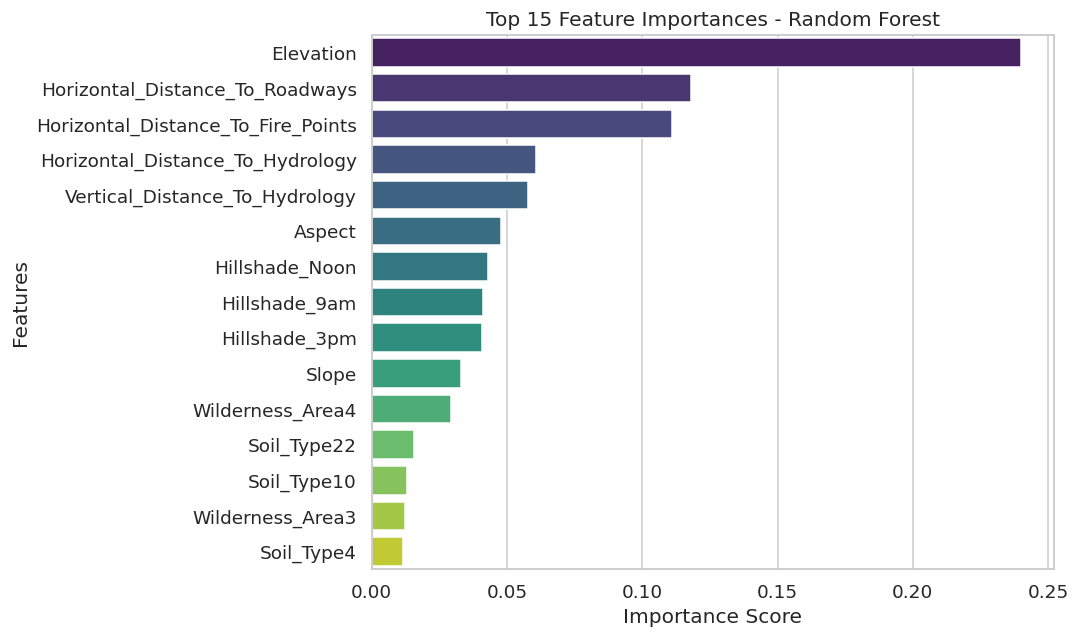

In [ ]:
#Visualize feature importances
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top 15 features
print(feature_importance.head(15))

# Plot top 15 feature importances
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(15),
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

 **Final Model Selection and Testing**

In [ ]:
#Random forest is the best model after hyperparameter tuning
best_model = best_rf_balanced_model

**Report Classification Results on Test Set**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Predictions
y_pred = best_model.predict(X_test)

# Accuracy
test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", round(test_accuracy, 4))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9202

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.90      0.92     42368
           1       0.91      0.96      0.93     56661
           2       0.88      0.93      0.91      7151
           3       0.89      0.74      0.81       549
           4       0.94      0.61      0.74      1899
           5       0.89      0.78      0.83      3473
           6       0.96      0.89      0.93      4102

    accuracy                           0.92    116203
   macro avg       0.92      0.83      0.87    116203
weighted avg       0.92      0.92      0.92    116203



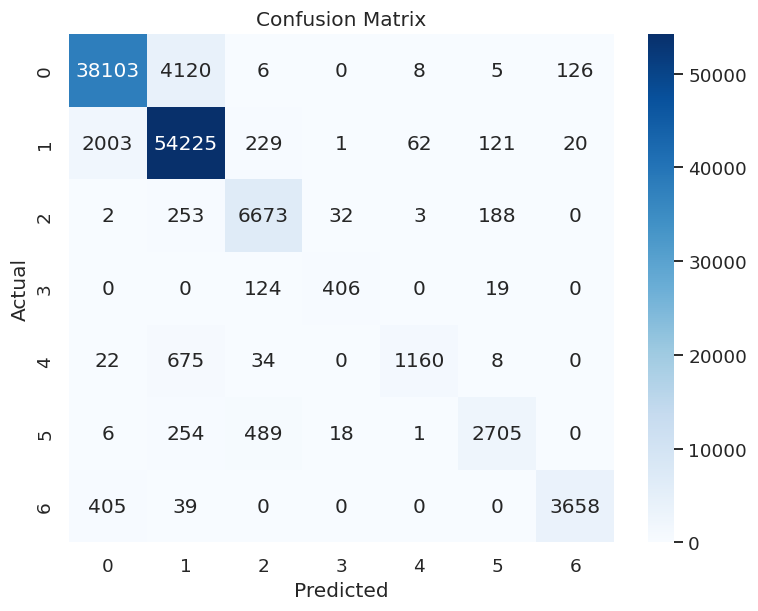

In [ ]:
#Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

# Ensure best_model is defined by assigning it directly from the best estimator found during random search.
best_model = random_search_rf.best_estimator_

# Training predictions
y_train_pred = best_model.predict(X_train)

# Test predictions
y_pred = best_model.predict(X_test)

# Accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_pred)

print("Training Accuracy :", round(train_accuracy, 4))
print("Testing Accuracy  :", round(test_accuracy, 4))

Training Accuracy : 0.9401
Testing Accuracy  : 0.9202


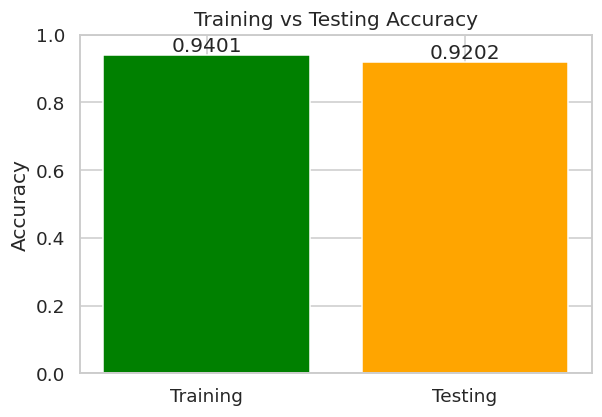

In [ ]:
import matplotlib.pyplot as plt # Ensure matplotlib is imported

plt.figure(figsize=(6,4))

scores = [train_accuracy, test_accuracy]
labels = ['Training', 'Testing']

plt.bar(labels, scores, color=['green', 'orange'])

plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.title('Training vs Testing Accuracy')

for i, score in enumerate(scores):
    plt.text(i,
             score + 0.01,
             f'{score:.4f}',
             ha='center')

plt.show()